# Actividad 1 — Regresión lineal
**Clase 4 · Aprendizaje Supervisado**

**Objetivo:** tomar un dataset con una variable objetivo continua y aplicar regresión lineal para predecirla a partir de otras variables.

## Fuente de los datos

| | |
|---|---|
| **Organismo** | INDEC — Instituto Nacional de Estadística y Censos de la República Argentina |
| **Área responsable** | Dirección Nacional de Estadísticas Económicas |
| **Indicador** | Utilización de la capacidad instalada en la industria (UCII) |
| **Cuadro descargado** | "Utilización de la capacidad instalada en la industria, nivel general y bloques sectoriales. Años 2016-2026" |
| **Archivo** | `datos/sh_capacidad_09_26.xls` (hoja "UCI - NG y bloques") |
| **Página de descarga** | https://www.indec.gob.ar/Nivel4/Tema/3/6/15 (Economía → Industria manufacturera → Utilización de la capacidad instalada → Series históricas) |
| **Enlace directo al archivo** | https://www.indec.gob.ar/ftp/cuadros/economia/sh_capacidad_09_26.xls |
| **Publicación** | Informe técnico del 15/09/2026 (último dato: julio de 2026) |
| **Fecha de descarga** | 27/09/2026 |
| **Informe técnico de referencia** | https://www.indec.gob.ar/uploads/informesdeprensa/capacidad_09_26CB3FA5C157.pdf |
| **Metodología** | https://www.indec.gob.ar/Nivel4/Tema/ftp/cuadros/economia/notas_metodologicas_capacidad_instalada_base2004.pdf |

**Qué mide:** la proporción (en %) de la capacidad productiva de la industria manufacturera que efectivamente se utiliza. Para calcularla, el INDEC considera la producción máxima que cada sector podría obtener con sus plantas actuales, usando el máximo de turnos posibles y descontando las paradas necesarias para mantenimiento. El relevamiento se hace sobre un panel de entre 600 y 700 empresas.

**Contenido:** datos mensuales de enero de 2016 a julio de 2026 (127 meses) del **nivel general** y de **12 bloques sectoriales**, expresados en porcentaje.

**Aclaraciones del propio INDEC que figuran en el archivo:**
- Los meses marcados con asterisco (por ejemplo `Enero*`) son **datos provisorios**, que pueden corregirse en publicaciones futuras.
- El bloque *Productos alimenticios y bebidas* no incluye la actividad vitivinícola ni los ingenios azucareros.
- El bloque *Sustancias y productos químicos* no incluye la industria farmacéutica.
- Los promedios pueden no coincidir exactamente por redondeo.

**Nota:** el INDEC reemplaza este archivo cada mes con el dato nuevo, y el nombre cambia según la fecha de publicación (`sh_capacidad_MM_AA.xls`). Para reproducir exactamente este análisis hay que usar la versión incluida en este repositorio.

**Cita:** INDEC (2026). *Utilización de la capacidad instalada en la industria, nivel general y bloques sectoriales. Años 2016-2026* [archivo xls]. Buenos Aires: Instituto Nacional de Estadística y Censos. Recuperado el 27/09/2026 de https://www.indec.gob.ar/Nivel4/Tema/3/6/15

## Planteo del problema

**Pregunta:** ¿se puede **pronosticar** la utilización de la capacidad instalada de la industria del **mes siguiente** a partir de lo que pasa en los sectores **este mes**?

- **Variable objetivo (continua):** UCII del nivel general del mes siguiente (%).
- **Modelo simple:** usa como predictor la UCII de la **industria automotriz** del mes actual.
- **Modelo multivariado:** usa la UCII del mes actual de los **4 sectores principales** de la industria (los de mayor peso en el nivel general, que identificamos en la exploración).

Método: 1) Preparación y organización de datos · 2) Exploración de los datos · 3) Creación de modelos de machine learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # para los gráficos 3D
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import sklearn.metrics as sm

## 1. Preparación y organización de datos
El archivo del INDEC está pensado para leerse en Excel, no para analizarse directamente: tiene títulos, filas vacías, una fila "Año 2016" que separa cada año, meses con asterisco (`Enero*` = dato provisorio) y notas al final. Hay que ordenarlo.

> Si al leer el archivo aparece un error que menciona `xlrd`, instalalo con `pip install xlrd` en la Terminal (se necesita para leer archivos `.xls` viejos).

In [2]:
# Archivo descargado del INDEC (ver sección "Fuente de los datos").
# Está guardado en la carpeta datos/ del repositorio.
crudo = pd.read_excel("../Datos/sh_capacidad_09_26.xls", header=None)
crudo.head(12)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Utilización de la capacidad instalada en la in...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Período,Nivel general,Productos alimenticios y bebidas,Productos del tabaco,Productos textiles,Papel y cartón,Edición e impresión,Refinación del petróleo,Sustancias y productos químicos,Productos de caucho y plástico,Productos minerales no metálicos,Industrias metálicas básicas,Industria automotriz,Metalmecánica excluida industria automotriz
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Porcentaje,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Año 2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Enero*,62.9,68.5,83.9,66.9,84.4,58.3,85.1,66.1,58.8,63.2,65.2,20.4,52.2


In [3]:
# Los nombres de las columnas están en la fila 2
columnas = list(crudo.iloc[2, 1:])
print(columnas)

['Nivel general', 'Productos alimenticios y bebidas', 'Productos del tabaco', 'Productos textiles', 'Papel y cartón', 'Edición e impresión', 'Refinación del petróleo', 'Sustancias y productos químicos', 'Productos de caucho y plástico', 'Productos minerales no metálicos', 'Industrias metálicas básicas', 'Industria automotriz', 'Metalmecánica excluida industria automotriz']


In [4]:
# Recorremos las filas: cuando aparece "Año XXXX" guardamos el año,
# y cada fila de mes la convertimos en una fecha junto con sus valores
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio",
         "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

filas = []
anio = None
for _, fila in crudo.iterrows():
    etiqueta = str(fila[0]).strip()
    if etiqueta.startswith("Año "):
        anio = int(etiqueta[4:])
    elif etiqueta.rstrip("*") in meses:
        mes = meses.index(etiqueta.rstrip("*")) + 1
        filas.append([pd.Timestamp(anio, mes, 1)] + list(fila[1:]))

df = pd.DataFrame(filas, columns=["fecha"] + columnas).set_index("fecha").astype(float)
df.head()

,Nivel general,Productos alimenticios y bebidas,Productos del tabaco,Productos textiles,Papel y cartón,Edición e impresión,Refinación del petróleo,Sustancias y productos químicos,Productos de caucho y plástico,Productos minerales no metálicos,Industrias metálicas básicas,Industria automotriz,Metalmecánica excluida industria automotriz
fecha,,,,,,,,,,,,,
2016-01-01,62.9,68.5,83.9,66.9,84.4,58.3,85.1,66.1,58.8,63.2,65.2,20.4,52.2
2016-02-01,64.2,66.8,81.3,72.2,79.0,53.6,86.8,66.8,53.6,73.1,70.7,43.1,51.1
2016-03-01,64.8,67.2,84.1,73.5,81.4,55.0,83.4,66.3,56.2,75.4,63.6,55.5,53.1
2016-04-01,64.8,63.5,81.4,74.4,83.8,58.5,82.0,67.9,60.2,75.4,65.2,54.6,53.2
2016-05-01,65.0,64.5,79.0,73.3,74.6,61.1,80.9,65.3,60.4,72.9,73.5,47.5,56.0


In [5]:
# Acortamos los nombres para que los gráficos se lean mejor
df.columns = ["nivel_general", "alimentos", "tabaco", "textiles", "papel",
              "edicion", "refinacion", "quimicos", "caucho_plastico",
              "minerales_no_met", "metalicas_basicas", "automotriz", "metalmecanica"]
df.head()

,nivel_general,alimentos,tabaco,textiles,papel,edicion,refinacion,quimicos,caucho_plastico,minerales_no_met,metalicas_basicas,automotriz,metalmecanica
fecha,,,,,,,,,,,,,
2016-01-01,62.9,68.5,83.9,66.9,84.4,58.3,85.1,66.1,58.8,63.2,65.2,20.4,52.2
2016-02-01,64.2,66.8,81.3,72.2,79.0,53.6,86.8,66.8,53.6,73.1,70.7,43.1,51.1
2016-03-01,64.8,67.2,84.1,73.5,81.4,55.0,83.4,66.3,56.2,75.4,63.6,55.5,53.1
2016-04-01,64.8,63.5,81.4,74.4,83.8,58.5,82.0,67.9,60.2,75.4,65.2,54.6,53.2
2016-05-01,65.0,64.5,79.0,73.3,74.6,61.1,80.9,65.3,60.4,72.9,73.5,47.5,56.0


In [6]:
print("Filas y columnas:", df.shape)
print("Desde", df.index.min().date(), "hasta", df.index.max().date())
print("\nValores faltantes por columna:")
print(df.isnull().sum())

Filas y columnas: (127, 13)
Desde 2016-01-01 hasta 2026-07-01

Valores faltantes por columna:
nivel_general        0
alimentos            0
tabaco               0
textiles             0
papel                0
edicion              0
refinacion           0
quimicos             0
caucho_plastico      0
minerales_no_met     0
metalicas_basicas    0
automotriz           0
metalmecanica        0
dtype: int64


Quedan 127 meses completos, sin valores faltantes. Los datos están listos para explorar.

## 2. Exploración de los datos (AED)

In [7]:
df.describe().round(1)

,nivel_general,alimentos,tabaco,textiles,papel,edicion,refinacion,quimicos,caucho_plastico,minerales_no_met,metalicas_basicas,automotriz,metalmecanica
count,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0
mean,61.7,62.9,60.8,51.1,72.8,55.9,78.9,66.7,51.5,67.1,72.2,46.5,48.8
std,4.9,3.4,13.6,11.8,7.0,4.7,6.7,5.8,7.3,11.2,10.1,13.3,7.8
min,42.0,54.5,0.0,4.2,57.7,41.3,46.2,47.5,31.7,22.5,25.1,0.0,20.1
25%,58.4,60.2,50.8,43.4,67.8,52.9,75.8,63.7,46.4,59.1,66.3,39.0,43.5
50%,62.0,63.3,61.3,51.6,72.9,56.1,79.9,67.9,52.6,70.7,73.3,47.5,49.9
75%,65.0,65.3,71.1,58.9,77.4,59.2,83.6,70.8,56.8,75.4,80.2,55.6,54.7
max,69.6,70.2,97.1,74.4,91.8,65.9,89.9,77.0,65.8,83.8,89.6,74.3,63.2


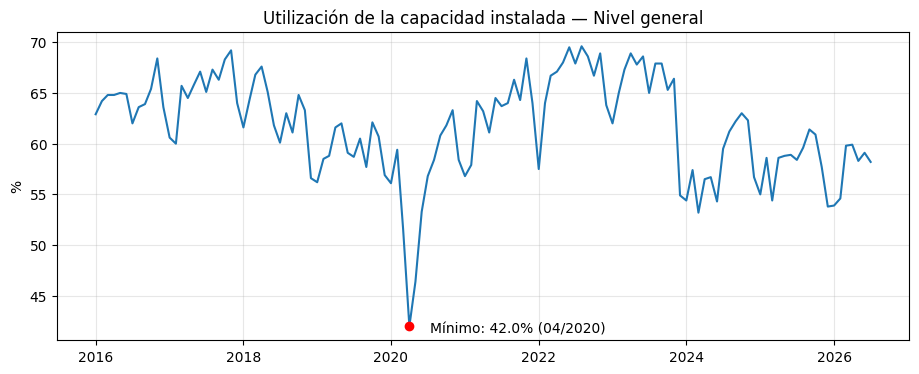

In [8]:
# Evolución del nivel general en el tiempo
plt.figure(figsize=(11, 4))
plt.plot(df.index, df["nivel_general"])
minimo = df["nivel_general"].idxmin()
plt.scatter(minimo, df.loc[minimo, "nivel_general"], color="red", zorder=3)
plt.annotate(f"Mínimo: {df.loc[minimo, 'nivel_general']}% ({minimo:%m/%Y})",
             (minimo, df.loc[minimo, "nivel_general"]), xytext=(15, -5), textcoords="offset points")
plt.title("Utilización de la capacidad instalada — Nivel general")
plt.ylabel("%")
plt.grid(alpha=0.3)
plt.show()

El valor más bajo de toda la serie es **abril de 2020 (42%)**, el primer mes completo de la cuarentena por COVID-19. Es un **valor atípico** real: no es un error de carga, sino un hecho excepcional.

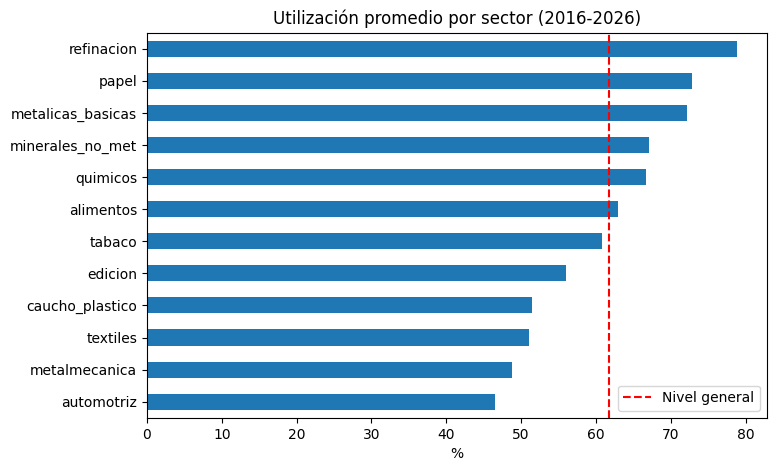

In [9]:
# Promedio de utilización de cada sector en todo el período
df.drop(columns="nivel_general").mean().sort_values().plot(kind="barh", figsize=(8, 5))
plt.axvline(df["nivel_general"].mean(), color="red", linestyle="--", label="Nivel general")
plt.title("Utilización promedio por sector (2016-2026)")
plt.xlabel("%")
plt.legend()
plt.show()

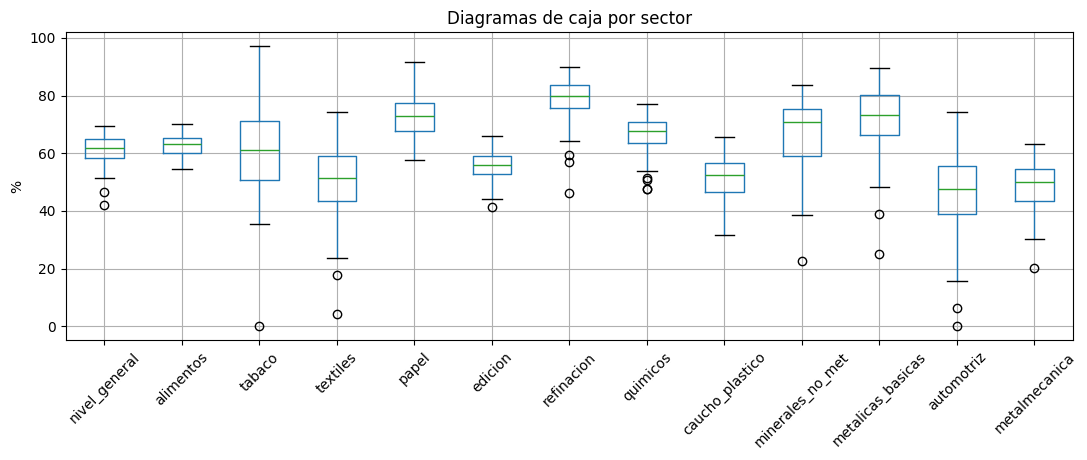

In [10]:
# Diagramas de caja: muestran la dispersión y los valores atípicos de cada sector
df.boxplot(figsize=(13, 4), rot=45)
plt.title("Diagramas de caja por sector")
plt.ylabel("%")
plt.show()

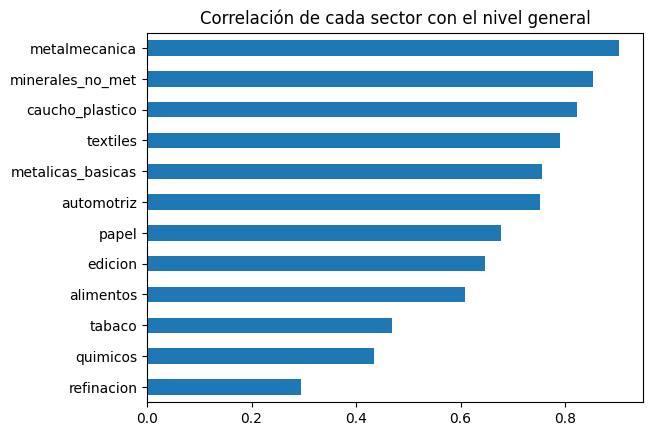

refinacion           0.29
quimicos             0.43
tabaco               0.47
alimentos            0.61
edicion              0.65
papel                0.68
automotriz           0.75
metalicas_basicas    0.75
textiles             0.79
caucho_plastico      0.82
minerales_no_met     0.85
metalmecanica        0.90
Name: nivel_general, dtype: float64

In [11]:
# ¿Qué sectores se mueven más parecido al nivel general?
correlaciones = df.corr()["nivel_general"].drop("nivel_general").sort_values()
correlaciones.plot(kind="barh")
plt.title("Correlación de cada sector con el nivel general")
plt.show()
correlaciones.round(2)

**Observaciones:**
- La refinación de petróleo y las industrias metálicas básicas son los sectores que más usan su capacidad; la industria automotriz y la metalmecánica, los que menos.
- La **metalmecánica** es el sector que más acompaña los movimientos del nivel general (correlación 0.90).
- La **refinación de petróleo** casi no se relaciona con el nivel general (0.29): funciona siempre alta, sin importar cómo le vaya al resto de la industria.
- La industria automotriz es la más variable (su caja es la más larga): tiene meses muy bajos, por ejemplo por vacaciones de planta o paradas de producción.

### ¿Cuáles son los 4 sectores principales?
El INDEC calcula el nivel general como un **promedio ponderado** de los sectores: cada uno pesa según su tamaño en la industria, pero esos pesos no vienen en el archivo. Podemos estimarlos con una regresión lineal entre el nivel general y los 12 sectores **del mismo mes**: los coeficientes que encuentre son los pesos.

Suma de los pesos: 0.999 (un promedio ponderado suma 1)


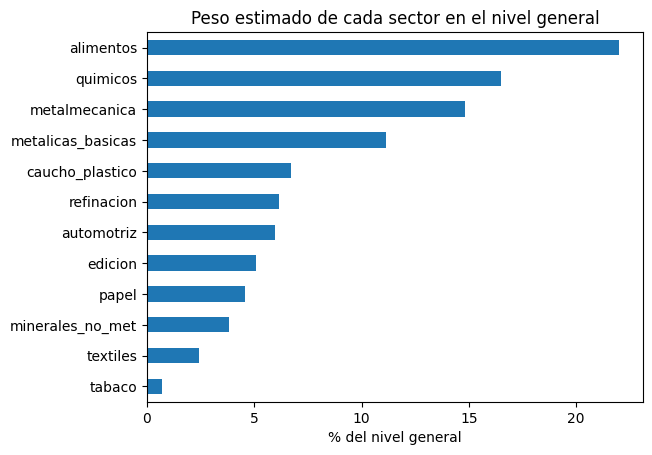

alimentos            22.0
quimicos             16.5
metalmecanica        14.8
metalicas_basicas    11.2
caucho_plastico       6.7
refinacion            6.2
automotriz            6.0
edicion               5.1
papel                 4.6
minerales_no_met      3.8
textiles              2.4
tabaco                0.7
dtype: float64

In [12]:
sectores = df.drop(columns="nivel_general")
estimador_pesos = linear_model.LinearRegression().fit(sectores, df["nivel_general"])
pesos = pd.Series(estimador_pesos.coef_, index=sectores.columns).sort_values(ascending=False)

print("Suma de los pesos:", round(pesos.sum(), 3), "(un promedio ponderado suma 1)")
(pesos * 100).sort_values().plot(kind="barh")
plt.title("Peso estimado de cada sector en el nivel general")
plt.xlabel("% del nivel general")
plt.show()
(pesos * 100).round(1)

In [13]:
principales = list(pesos.index[:4])
print("Los 4 sectores principales son:", principales)
print("Juntos representan el", round(pesos[:4].sum() * 100, 1), "% del nivel general")

Los 4 sectores principales son: ['alimentos', 'quimicos', 'metalmecanica', 'metalicas_basicas']
Juntos representan el 64.5 % del nivel general


Los 4 sectores de mayor peso son **alimentos y bebidas**, **sustancias y productos químicos**, **metalmecánica** e **industrias metálicas básicas**. Juntos explican más de la mitad del nivel general, así que son los candidatos naturales para el modelo multivariado.

### Creamos la variable objetivo: el nivel general del mes siguiente
Para pronosticar, cada fila tiene que tener los datos de **este mes** y, como objetivo, el nivel general del **mes siguiente**. Eso se hace con `shift(-1)`, que "sube" la columna una fila.

In [14]:
df["ng_mes_siguiente"] = df["nivel_general"].shift(-1)
df[["nivel_general", "ng_mes_siguiente", "automotriz"]].tail(4)

,nivel_general,ng_mes_siguiente,automotriz
fecha,,,
2026-04-01,59.9,58.3,46.5
2026-05-01,58.3,59.1,45.5
2026-06-01,59.1,58.2,45.5
2026-07-01,58.2,NaN,39.0


El último mes (julio 2026) queda sin objetivo, porque el dato de agosto todavía no se publicó. Lo separamos: no sirve para entrenar ni evaluar, pero **lo vamos a usar al final para hacer un pronóstico real**.

In [15]:
ultimo_mes = df.iloc[[-1]]           # julio 2026, para el pronóstico final
datos = df.dropna(subset=["ng_mes_siguiente"])
print("Meses disponibles para el modelo:", len(datos))

Meses disponibles para el modelo: 126


In [16]:
# ¿Qué tanto se relacionan los predictores de este mes con el nivel general del mes siguiente?
datos[["automotriz"] + principales].corrwith(datos["ng_mes_siguiente"]).round(2)

automotriz           0.53
alimentos            0.43
quimicos             0.30
metalmecanica        0.78
metalicas_basicas    0.57
dtype: float64

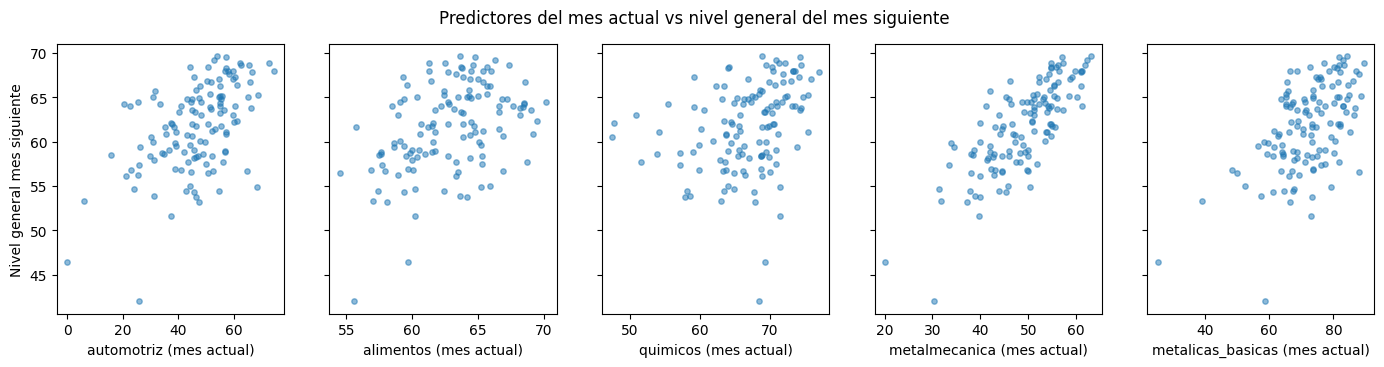

In [17]:
fig, ax = plt.subplots(1, 5, figsize=(17, 3.5), sharey=True)
for eje, col in zip(ax, ["automotriz"] + principales):
    eje.scatter(datos[col], datos["ng_mes_siguiente"], alpha=0.5, s=15)
    eje.set_xlabel(f"{col} (mes actual)")
ax[0].set_ylabel("Nivel general mes siguiente")
plt.suptitle("Predictores del mes actual vs nivel general del mes siguiente")
plt.show()

La automotriz tiene una relación dispersa con el mes siguiente (correlación 0.53): hay mucha variación que no sigue la tendencia. La metalmecánica, en cambio, muestra la relación más clara (0.78).

## 3. Creación de modelos de machine learning

| Modelo | Variables predictoras (mes actual) | Visualización |
|---|---|---|
| **Simple** | automotriz | 2D: recta |
| **Multivariado** | alimentos, químicos, metalmecánica, metálicas básicas | 2D y 3D: plano |

### 3.1 División en entrenamiento y prueba
- **Entrenamiento (80%)**: los meses con los que el modelo aprende.
- **Prueba (20%)**: meses que el modelo nunca vio, para comprobar si predice bien.

Usamos la misma división para los dos modelos, así la comparación es justa. `random_state=42` hace que la división sea siempre la misma.

In [18]:
y = datos["ng_mes_siguiente"]
X = datos[["automotriz"] + principales]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Meses de entrenamiento:", len(X_train))
print("Meses de prueba:", len(X_test))

Meses de entrenamiento: 100
Meses de prueba: 26


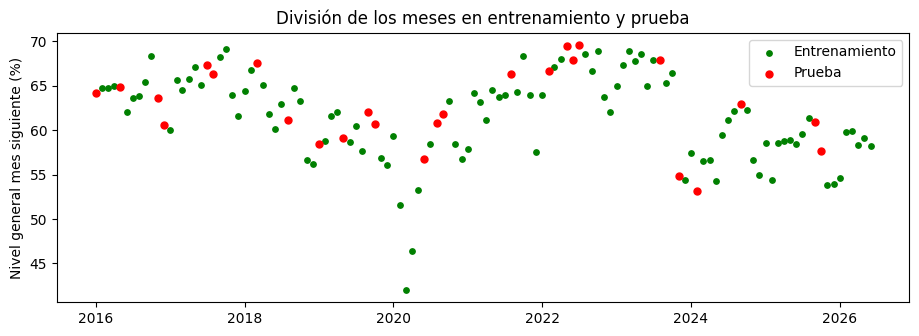

In [19]:
plt.figure(figsize=(11, 3.5))
plt.scatter(y_train.index, y_train, s=15, label="Entrenamiento", color="green")
plt.scatter(y_test.index, y_test, s=25, label="Prueba", color="red")
plt.title("División de los meses en entrenamiento y prueba")
plt.ylabel("Nivel general mes siguiente (%)")
plt.legend()
plt.show()

Definimos funciones que vamos a reutilizar con cada modelo:
- `mostrar_metricas`: calcula las métricas de evaluación vistas en clase.
- `calcular_residuos`: calcula el **residuo** de cada mes, la diferencia entre el valor real y el predicho:

$$\\text{residuo} = y_{real} - y_{predicho}$$

Un residuo positivo significa que el modelo predijo **menos** de lo real; uno negativo, que predijo **de más**.

In [20]:
def mostrar_metricas(y_real, y_pred):
    print("Error absoluto medio (MAE) =", round(sm.mean_absolute_error(y_real, y_pred), 3))
    print("Error cuadrático medio (MSE) =", round(sm.mean_squared_error(y_real, y_pred), 3))
    print("Error absoluto mediana =", round(sm.median_absolute_error(y_real, y_pred), 3))
    print("Puntuación de varianza explicada =", round(sm.explained_variance_score(y_real, y_pred), 3))
    print("Puntuación R2 =", round(sm.r2_score(y_real, y_pred), 3))

def calcular_residuos(y_real, y_pred):
    tabla = pd.DataFrame({"real": y_real, "predicho": np.round(y_pred, 2)})
    tabla["residuo"] = (tabla["real"] - tabla["predicho"]).round(2)
    # El índice es el mes actual; el pronóstico corresponde al mes siguiente
    tabla.index = (tabla.index + pd.DateOffset(months=1)).strftime("%m/%Y")
    tabla.index.name = "mes pronosticado"
    return tabla.sort_index(key=lambda i: pd.to_datetime(i, format="%m/%Y"))

def graficar_residuos(tabla, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(tabla["predicho"], tabla["residuo"])
    ax[0].axhline(0, color="black", linestyle="--")
    ax[0].set_xlabel("Valor predicho (%)"); ax[0].set_ylabel("Residuo")
    ax[0].set_title("Residuos vs valores predichos")
    ax[1].hist(tabla["residuo"], bins=10, edgecolor="black")
    ax[1].axvline(0, color="black", linestyle="--")
    ax[1].set_xlabel("Residuo"); ax[1].set_ylabel("Cantidad de meses")
    ax[1].set_title("Distribución de los residuos")
    fig.suptitle(titulo)
    plt.show()

### 3.2 Modelo simple: automotriz → nivel general del mes siguiente
#### Entrenamiento

In [21]:
modelo_simple = linear_model.LinearRegression()
modelo_simple.fit(X_train[["automotriz"]], y_train)
print(f"Ecuación: ng_mes_siguiente = {modelo_simple.coef_[0]:.3f} * automotriz + {modelo_simple.intercept_:.3f}")

Ecuación: ng_mes_siguiente = 0.218 * automotriz + 51.321


Por cada punto que sube la utilización de la automotriz, el modelo espera que el nivel general del mes siguiente suba unas dos décimas.

#### Evaluación

In [22]:
pred_simple = modelo_simple.predict(X_test[["automotriz"]])
mostrar_metricas(y_test, pred_simple)

Error absoluto medio (MAE) = 3.512
Error cuadrático medio (MSE) = 20.795
Error absoluto mediana = 3.072
Puntuación de varianza explicada = -0.029
Puntuación R2 = -0.074


El **R2 es negativo**: como vimos en clase, esto puede pasar y significa que el modelo predice **peor que si usáramos siempre el promedio** de los datos. La automotriz sola no sirve para anticipar el mes siguiente.

#### Cálculo de residuos

In [23]:
residuos_simple = calcular_residuos(y_test, pred_simple)
residuos_simple

,real,predicho,residuo
mes pronosticado,,,
02/2016,64.2,55.78,8.42
06/2016,64.9,61.70,3.20
12/2016,63.6,63.62,-0.02
01/2017,60.6,61.15,-0.55
08/2017,67.3,61.26,6.04
09/2017,66.3,63.36,2.94
04/2018,67.6,64.04,3.56
09/2018,61.1,63.84,-2.74
02/2019,58.5,54.75,3.75


Residuo promedio: 0.936
Mayor error por exceso: -11.34 en 12/2023
Mayor error por defecto: 8.42 en 02/2016


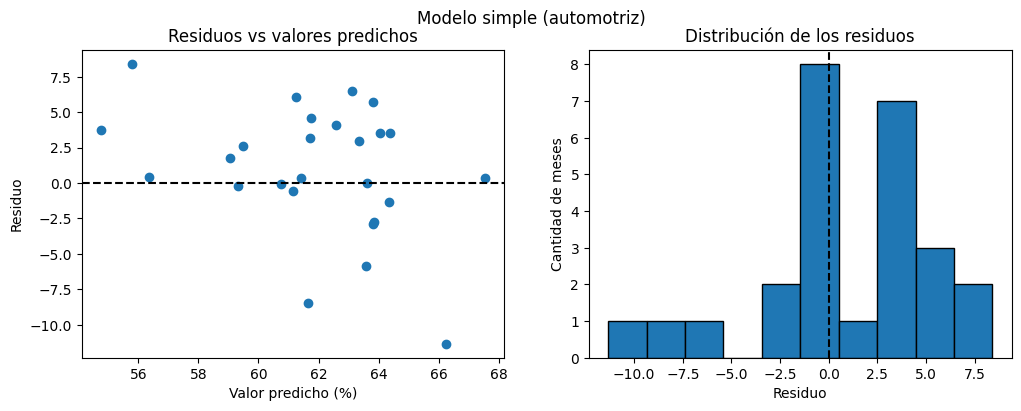

In [24]:
print("Residuo promedio:", round(residuos_simple["residuo"].mean(), 3))
print("Mayor error por exceso:", residuos_simple["residuo"].min(), "en", residuos_simple["residuo"].idxmin())
print("Mayor error por defecto:", residuos_simple["residuo"].max(), "en", residuos_simple["residuo"].idxmax())
graficar_residuos(residuos_simple, "Modelo simple (automotriz)")

#### Predicciones y visualización 2D

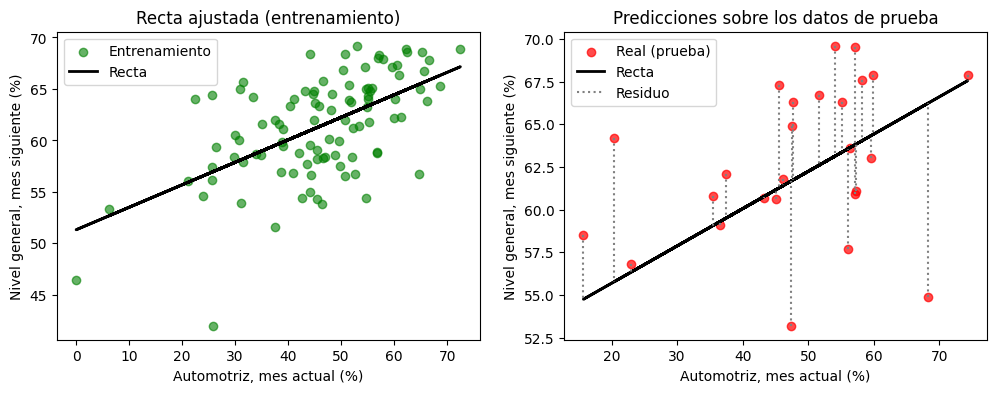

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(X_train["automotriz"], y_train, color="green", alpha=0.6, label="Entrenamiento")
ax[0].plot(X_train["automotriz"], modelo_simple.predict(X_train[["automotriz"]]), color="black", linewidth=2, label="Recta")
ax[0].set_title("Recta ajustada (entrenamiento)")

ax[1].scatter(X_test["automotriz"], y_test, color="red", alpha=0.7, label="Real (prueba)")
ax[1].plot(X_test["automotriz"], pred_simple, color="black", linewidth=2, label="Recta")
ax[1].vlines(X_test["automotriz"], y_test, pred_simple, color="gray", linestyle=":", label="Residuo")
ax[1].set_title("Predicciones sobre los datos de prueba")
for eje in ax:
    eje.set_xlabel("Automotriz, mes actual (%)"); eje.set_ylabel("Nivel general, mes siguiente (%)"); eje.legend()
plt.show()

La recta es bastante "plana" y los puntos están muy dispersos a su alrededor: las líneas grises (residuos) son largas. La automotriz tiene variaciones muy bruscas (vacaciones de planta en enero, paradas por falta de demanda o de exportaciones a Brasil) que no se trasladan al resto de la industria.

### 3.3 Modelo multivariado: 4 sectores principales → nivel general del mes siguiente
#### Entrenamiento

In [26]:
modelo_multi = linear_model.LinearRegression()
modelo_multi.fit(X_train[principales], y_train)

coeficientes = pd.Series(modelo_multi.coef_, index=principales).round(3)
print("Ordenada al origen:", round(modelo_multi.intercept_, 3))
coeficientes

Ordenada al origen: 28.375


alimentos            0.002
quimicos             0.115
metalmecanica        0.419
metalicas_basicas    0.069
dtype: float64

La **metalmecánica** es, por lejos, la variable con más influencia en el pronóstico: su coeficiente es varias veces mayor que el de los demás sectores.

Un resultado curioso: **alimentos y bebidas** es el sector de mayor peso en el nivel general, pero su coeficiente es casi 0, o sea que prácticamente no ayuda a pronosticar el mes siguiente. Tiene sentido: la producción de alimentos es muy estable (la gente sigue comiendo aunque la economía ande mal), así que casi no "avisa" cuando la industria va a subir o bajar. La metalmecánica, en cambio, depende de la inversión y reacciona rápido a los cambios de la economía.

#### Evaluación

In [27]:
pred_multi = modelo_multi.predict(X_test[principales])
mostrar_metricas(y_test, pred_multi)

Error absoluto medio (MAE) = 2.151
Error cuadrático medio (MSE) = 8.22
Error absoluto mediana = 1.96
Puntuación de varianza explicada = 0.576
Puntuación R2 = 0.575


#### Cálculo de residuos

In [28]:
residuos_multi = calcular_residuos(y_test, pred_multi)
residuos_multi

,real,predicho,residuo
mes pronosticado,,,
02/2016,64.2,62.50,1.70
06/2016,64.9,64.57,0.33
12/2016,63.6,65.98,-2.38
01/2017,60.6,63.26,-2.66
08/2017,67.3,65.36,1.94
09/2017,66.3,66.78,-0.48
04/2018,67.6,65.62,1.98
09/2018,61.1,63.21,-2.11
02/2019,58.5,57.47,1.03


Residuo promedio: 0.109
Mayor error por exceso: -8.39 en 12/2023
Mayor error por defecto: 5.88 en 10/2019


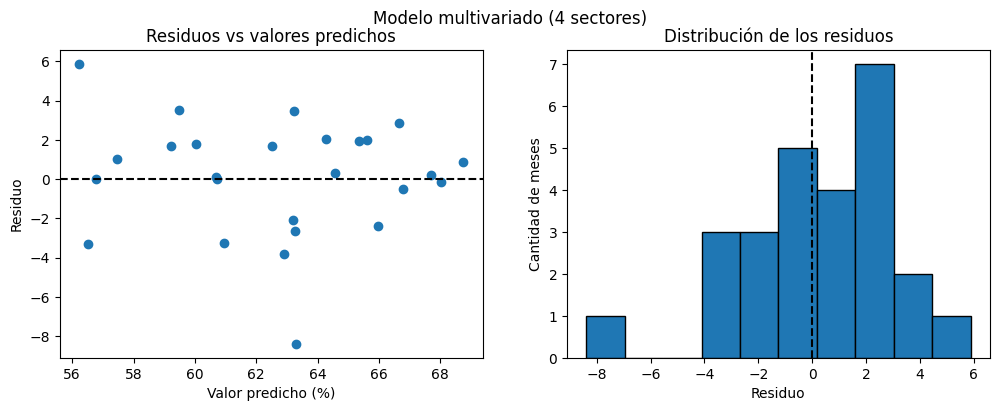

In [29]:
print("Residuo promedio:", round(residuos_multi["residuo"].mean(), 3))
print("Mayor error por exceso:", residuos_multi["residuo"].min(), "en", residuos_multi["residuo"].idxmin())
print("Mayor error por defecto:", residuos_multi["residuo"].max(), "en", residuos_multi["residuo"].idxmax())
graficar_residuos(residuos_multi, "Modelo multivariado (4 sectores)")

#### Predicciones y visualización 2D

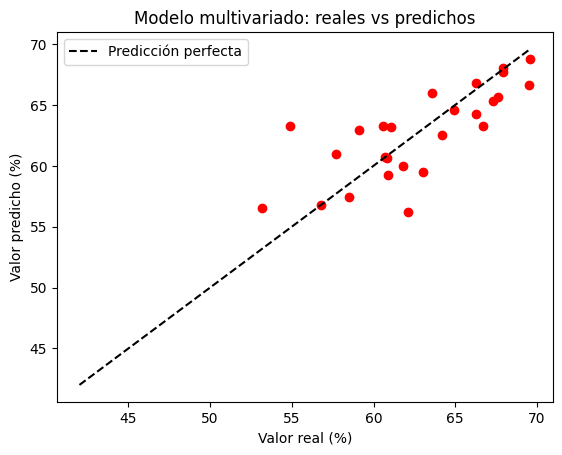

In [30]:
plt.scatter(y_test, pred_multi, color="red")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", label="Predicción perfecta")
plt.xlabel("Valor real (%)"); plt.ylabel("Valor predicho (%)")
plt.title("Modelo multivariado: reales vs predichos")
plt.legend()
plt.show()

#### Visualización 3D
Con 4 variables el modelo "vive" en 5 dimensiones y no se puede dibujar entero. Lo que sí podemos hacer es mostrar el **plano** que forma con las **dos variables de mayor influencia**, dejando las otras dos fijas en su valor promedio.

Ejes del gráfico 3D: metalmecanica y metalicas_basicas


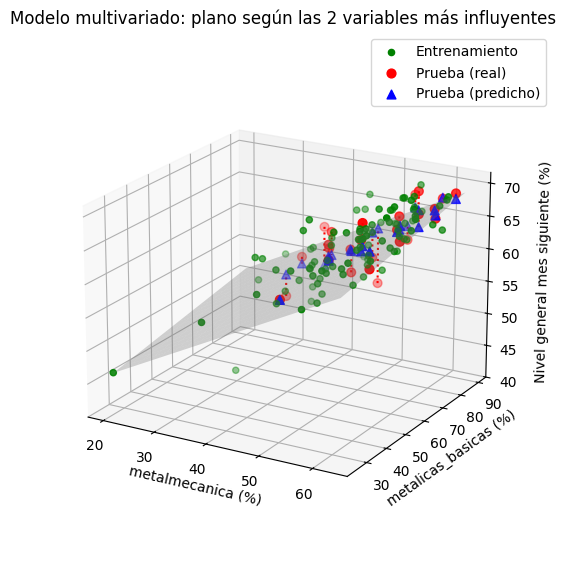

In [31]:
# Las dos variables con mayor influencia: coeficiente x desvío estándar de la variable
influencia = (pd.Series(modelo_multi.coef_, index=principales) * X_train[principales].std()).abs()
v1, v2 = influencia.sort_values(ascending=False).index[:2]
print("Ejes del gráfico 3D:", v1, "y", v2)

g1 = np.linspace(X[v1].min(), X[v1].max(), 20)
g2 = np.linspace(X[v2].min(), X[v2].max(), 20)
G1, G2 = np.meshgrid(g1, g2)
malla = pd.DataFrame({v: np.full(G1.size, X_train[v].mean()) for v in principales})
malla[v1], malla[v2] = G1.ravel(), G2.ravel()
plano = modelo_multi.predict(malla[principales]).reshape(G1.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(G1, G2, plano, alpha=0.3, color="gray")
ax.scatter(X_train[v1], X_train[v2], y_train, color="green", label="Entrenamiento")
ax.scatter(X_test[v1], X_test[v2], y_test, color="red", s=40, label="Prueba (real)")
ax.scatter(X_test[v1], X_test[v2], pred_multi, color="blue", marker="^", s=40, label="Prueba (predicho)")
for a, b, real, pred in zip(X_test[v1], X_test[v2], y_test, pred_multi):
    ax.plot([a, a], [b, b], [real, pred], color="red", linestyle=":")
ax.set_xlabel(f"{v1} (%)")
ax.set_ylabel(f"{v2} (%)")
ax.set_zlabel("Nivel general mes siguiente (%)", labelpad=8)
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Modelo multivariado: plano según las 2 variables más influyentes")
ax.view_init(elev=20, azim=-60)
ax.legend()
plt.show()

El plano gris muestra cómo cambia el pronóstico al moverse estas dos variables. Los puntos rojos son los valores reales de prueba, los triángulos azules lo que predijo el modelo, y las líneas punteadas son los residuos.

> Tip: si en Jupyter escribís `%matplotlib notebook` (o `%matplotlib widget`) al principio de la celda, podés girar el gráfico 3D con el mouse.

### 3.4 Comparación de los modelos
Agregamos una referencia muy simple, el **pronóstico ingenuo**: "el mes que viene va a ser igual que este mes". Un modelo útil debería superarlo.

In [32]:
pred_ingenuo = X_test.join(datos["nivel_general"])["nivel_general"].values

comparacion = pd.DataFrame({
    nombre: {"MAE": sm.mean_absolute_error(y_test, pred),
             "MSE": sm.mean_squared_error(y_test, pred),
             "Varianza explicada": sm.explained_variance_score(y_test, pred),
             "R2": sm.r2_score(y_test, pred)}
    for nombre, pred in [("Simple (automotriz)", pred_simple),
                         ("Multivariado (4 sectores)", pred_multi),
                         ("Ingenuo (igual al mes actual)", pred_ingenuo)]
}).T.round(3)
comparacion

,MAE,MSE,Varianza explicada,R2
Simple (automotriz),3.512,20.795,-0.029,-0.074
Multivariado (4 sectores),2.151,8.220,0.576,0.575
Ingenuo (igual al mes actual),2.423,10.737,0.452,0.445


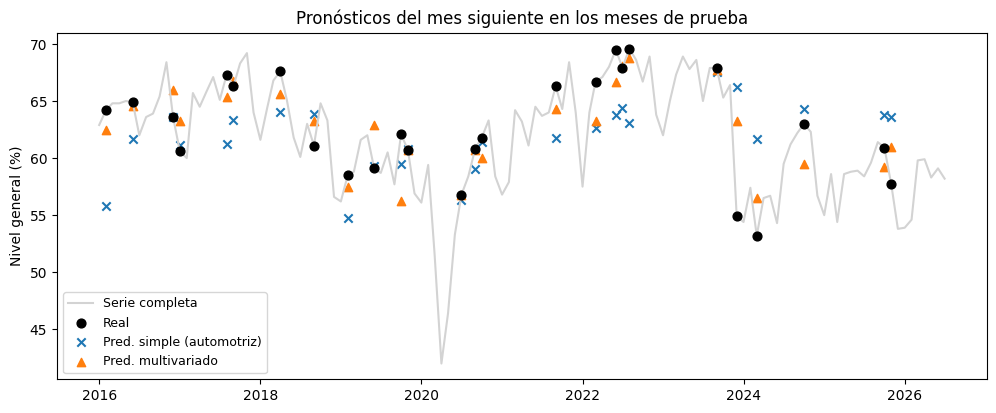

In [33]:
orden = np.argsort(y_test.index)
meses_pron = (y_test.index + pd.DateOffset(months=1))[orden]

plt.figure(figsize=(12, 4.5))
plt.plot(df.index, df["nivel_general"], color="lightgray", label="Serie completa")
plt.scatter(meses_pron, y_test.values[orden], color="black", s=40, label="Real", zorder=3)
plt.scatter(meses_pron, pred_simple[orden], marker="x", label="Pred. simple (automotriz)")
plt.scatter(meses_pron, pred_multi[orden], marker="^", label="Pred. multivariado")
plt.ylabel("Nivel general (%)")
plt.title("Pronósticos del mes siguiente en los meses de prueba")
plt.legend(fontsize=9)
plt.show()

### 3.5 Pronóstico real: agosto de 2026
Usamos los datos de **julio de 2026** (el último mes publicado) para pronosticar **agosto de 2026**, que todavía no se conoce. El INDEC lo publica el **15/10/2026**: ahí se puede comprobar si el modelo acertó.

In [34]:
print("Datos de julio 2026:")
print(ultimo_mes[["nivel_general", "automotriz"] + principales].T.rename(columns=lambda c: "valor"))
print()
print("Pronóstico agosto 2026 — modelo simple:      ", round(modelo_simple.predict(ultimo_mes[["automotriz"]])[0], 1), "%")
print("Pronóstico agosto 2026 — modelo multivariado:", round(modelo_multi.predict(ultimo_mes[principales])[0], 1), "%")

Datos de julio 2026:
fecha              valor
nivel_general       58.2
automotriz          39.0
alimentos           66.0
quimicos            61.4
metalmecanica       38.3
metalicas_basicas   71.8

Pronóstico agosto 2026 — modelo simple:       59.8 %
Pronóstico agosto 2026 — modelo multivariado: 56.6 %


### 3.6 Regresión contraída (Ridge)
Aplicamos Ridge al modelo multivariado para ver si la penalización mejora el pronóstico (por ejemplo, reduciendo la influencia de valores atípicos como abril de 2020).

In [35]:
for alpha in [0.1, 1, 10, 100, 1000]:
    ridge = linear_model.Ridge(alpha=alpha).fit(X_train[principales], y_train)
    print(f"Ridge alpha={alpha:>6} -> R2 = {sm.r2_score(y_test, ridge.predict(X_test[principales])):.3f}")

Ridge alpha=   0.1 -> R2 = 0.575
Ridge alpha=     1 -> R2 = 0.575
Ridge alpha=    10 -> R2 = 0.576
Ridge alpha=   100 -> R2 = 0.578
Ridge alpha=  1000 -> R2 = 0.578


Los resultados de Ridge son prácticamente iguales a los de la regresión lineal común: con solo 4 variables y en escalas parecidas, la penalización casi no cambia los coeficientes.

### 3.7 Una prueba más exigente: dividir por tiempo
La división aleatoria que usamos (la vista en clase) mezcla meses de todos los años: el modelo puede entrenar con marzo 2023 y "predecir" febrero 2023. En un pronóstico real solo se conoce el pasado. Probemos entrenar con los primeros años y evaluar con los **últimos** meses (`shuffle=False`):

In [36]:
X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Entrenamiento hasta:", X_tr_t.index.max().strftime("%m/%Y"), "| Prueba desde:", X_te_t.index.min().strftime("%m/%Y"))

for nombre, vars_ in [("Simple (automotriz)", ["automotriz"]), ("Multivariado (4 sectores)", principales)]:
    m = linear_model.LinearRegression().fit(X_tr_t[vars_], y_tr_t)
    p = m.predict(X_te_t[vars_])
    print(f"{nombre}: MAE = {sm.mean_absolute_error(y_te_t, p):.2f}  R2 = {sm.r2_score(y_te_t, p):.3f}")
ingenuo_t = X_te_t.join(datos["nivel_general"])["nivel_general"]
print(f"Ingenuo: MAE = {sm.mean_absolute_error(y_te_t, ingenuo_t):.2f}  R2 = {sm.r2_score(y_te_t, ingenuo_t):.3f}")

Entrenamiento hasta: 04/2024 | Prueba desde: 05/2024
Simple (automotriz): MAE = 4.71  R2 = -2.972
Multivariado (4 sectores): MAE = 2.34  R2 = -0.144
Ingenuo: MAE = 2.00  R2 = 0.015


Con esta división los resultados empeoran mucho: el período 2024-2026 se comporta distinto de los años anteriores, y los modelos entrenados con el pasado no lo anticipan bien. Esto muestra que pronosticar series económicas es difícil y que la forma de dividir los datos cambia mucho la evaluación.

## 4. Conclusiones

| Modelo | MAE | R2 |
|---|---|---|
| Simple (automotriz) | 3.51 | −0.07 |
| Multivariado (4 sectores principales) | 2.15 | 0.58 |
| Referencia ingenua (igual al mes actual) | 2.42 | 0.45 |

- La **automotriz sola no sirve para pronosticar** el nivel general del mes siguiente: su R2 es negativo, es decir, predice peor que el promedio. El sector tiene cambios muy bruscos y propios (vacaciones de planta, paradas por caída de las exportaciones a Brasil) que no se trasladan al resto de la industria.
- El **modelo multivariado** con los 4 sectores principales funciona bastante mejor: explica alrededor del 58% de la variación y se equivoca en promedio unos 2 puntos porcentuales. También supera a la referencia ingenua de "el mes que viene es igual a este".
- Dentro de ese modelo, la **metalmecánica** es la que más aporta. Alimentos y bebidas, aunque es el sector más grande, casi no ayuda a pronosticar porque es muy estable.
- Los **residuos** se reparten alrededor de 0, pero hay meses con errores grandes que coinciden con cambios bruscos de la economía, como diciembre de 2023. Ningún modelo basado solo en el mes anterior puede anticipar ese tipo de shocks.
- **Ridge** no mejora de forma apreciable el resultado.
- Con una **división por tiempo** (entrenar con el pasado y evaluar con 2024-2026) los modelos empeoran y no superan a la referencia ingenua. Para pronosticar de verdad habría que usar técnicas específicas de series de tiempo y agregar más información (por ejemplo, el mes del año para captar la estacionalidad).
- **Pronóstico para agosto de 2026:** el modelo multivariado estima **56.6%**. El dato real se publica el 15/10/2026 y permite comprobar el modelo con un mes que nunca vio.